In [52]:
## 1. Project Objective

# This project demonstrates how Python can be used for basic data extraction and data cleaning.
# GDP data is extracted from a website and processed using libraries such as Pandas and NumPy.
# The dataset is cleaned by handling duplicates and transforming the data format.
# The GDP values are converted into appropriate units and the final cleaned dataset is exported as a CSV file

In [53]:
## Dataset Description
# The dataset contains nominal GDP estimates of countries obtained from Wikipedia.
# GDP values are originally provided in Million USD and were converted to Billion USD for easier comparison.

In [54]:
## 2. Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [55]:
## 3. Data Extraction

url = "https://web.archive.org/web/20230902185326/https://en.wikipedia.org/wiki/List_of_countries_by_GDP_%28nominal%29"  # store the webpage link

tables = pd.read_html(url) # extracts all tables

gdp = tables[3] # selects the first table (GDP table)

In [56]:
gdp.head()

Country/Territory UN region IMF[1][13]            World Bank[14]             \
  Country/Territory UN region   Estimate       Year       Estimate       Year   
0             World         —  105568776       2023      100562011       2022   
1     United States  Americas   26854599       2023       25462700       2022   
2             China      Asia   19373586  [n 1]2023       17963171  [n 3]2022   
3             Japan      Asia    4409738       2023        4231141       2022   
4           Germany    Europe    4308854       2023        4072192       2022   

  United Nations[15]             
            Estimate       Year  
0           96698005       2021  
1           23315081       2021  
2           17734131  [n 1]2021  
3            4940878       2021  
4            4259935       2021

In [57]:
gdp.columns

MultiIndex([( 'Country/Territory', 'Country/Territory'),
            (         'UN region',         'UN region'),
            (        'IMF[1][13]',          'Estimate'),
            (        'IMF[1][13]',              'Year'),
            (    'World Bank[14]',          'Estimate'),
            (    'World Bank[14]',              'Year'),
            ('United Nations[15]',          'Estimate'),
            ('United Nations[15]',              'Year')],
           )

In [58]:
gdp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   (Country/Territory, Country/Territory)  214 non-null    object
 1   (UN region, UN region)                  214 non-null    object
 2   (IMF[1][13], Estimate)                  214 non-null    object
 3   (IMF[1][13], Year)                      214 non-null    object
 4   (World Bank[14], Estimate)              214 non-null    object
 5   (World Bank[14], Year)                  214 non-null    object
 6   (United Nations[15], Estimate)          214 non-null    object
 7   (United Nations[15], Year)              214 non-null    object
dtypes: object(8)
memory usage: 13.5+ KB


In [59]:
gdp = gdp[[('Country/Territory', 'Country/Territory'),
           ('IMF[1][13]', 'Estimate')]]

gdp.head(20)

,Country/Territory,IMF[1][13]
,Country/Territory,Estimate
0,World,105568776
1,United States,26854599
2,China,19373586
3,Japan,4409738
4,Germany,4308854
5,India,3736882
6,United Kingdom,3158938
7,France,2923489
8,Italy,2169745


In [60]:
## 4. Data Cleaning & Transformation

gdp = gdp.rename(columns={"Country/Territory":"Country"})
gdp = gdp.rename(columns={"IMF[1][13]":"GDP(Million USD)"})
gdp.head()

,Country,GDP(Million USD)
,Country,Estimate
0,World,105568776
1,United States,26854599
2,China,19373586
3,Japan,4409738
4,Germany,4308854


In [61]:
# Identifying rows where GDP value is missing
gdp = gdp.dropna(subset=[("GDP(Million USD)", "Estimate")])

In [62]:
gdp.isnull().sum()

,,0
Country,Country,0
GDP(Million USD),Estimate,0


In [63]:
# strip spaces from all string cells
gdp = gdp.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# replace fake missing values with NaN
gdp.replace(["", "-", "—", "NA", "N/A"], np.nan, inplace=True)

# remove rows with any NaN
gdp.dropna(inplace=True)

print(gdp)

              Country GDP(Million USD)
              Country         Estimate
0               World        105568776
1       United States         26854599
2               China         19373586
3               Japan          4409738
4             Germany          4308854
..                ...              ...
206  Marshall Islands              291
208             Palau              262
210          Kiribati              248
211             Nauru              151
213            Tuvalu               65

[192 rows x 2 columns]


In [64]:
# Remove rows where GDP value is missing after numeric conversion
# Remove rows where GDP is missing
gdp = gdp.dropna()

gdp.isnull().sum()

,,0
Country,Country,0
GDP(Million USD),Estimate,0


In [65]:
gdp = gdp.reset_index(drop=True)

In [66]:
# Remove the first row (World total) since it is not a country
gdp = gdp.iloc[1:]

gdp.head()

,Country,GDP(Million USD)
,Country,Estimate
1,United States,26854599
2,China,19373586
3,Japan,4409738
4,Germany,4308854
5,India,3736882


In [67]:
gdp.columns = gdp.columns.get_level_values(0)
gdp.columns

Index(['Country', 'GDP(Million USD)'], dtype='object')

In [68]:
# Replace missing GDP values represented by "—" with NaN
gdp["GDP(Million USD)"] = gdp["GDP(Million USD)"].replace("—", np.nan)

# Convert GDP column to numeric
gdp["GDP(Million USD)"] = pd.to_numeric(gdp["GDP(Million USD)"], errors="coerce")

gdp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191 entries, 1 to 191
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Country           191 non-null    object
 1   GDP(Million USD)  191 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 3.1+ KB


In [69]:
# Convert GDP from Million USD to Billion USD
gdp["GDP(Billion USD)"] = (gdp["GDP(Million USD)"] / 1000).round(2)

gdp.head()

,Country,GDP(Million USD),GDP(Billion USD)
1,United States,26854599,26854.60
2,China,19373586,19373.59
3,Japan,4409738,4409.74
4,Germany,4308854,4308.85
5,India,3736882,3736.88


In [70]:
gdp.sort_values(by="GDP(Billion USD)", ascending=False).head(10)

,Country,GDP(Million USD),GDP(Billion USD)
1,United States,26854599,26854.60
2,China,19373586,19373.59
3,Japan,4409738,4409.74
4,Germany,4308854,4308.85
5,India,3736882,3736.88
6,United Kingdom,3158938,3158.94
7,France,2923489,2923.49
8,Italy,2169745,2169.74
9,Canada,2089672,2089.67
10,Brazil,2081235,2081.24


In [71]:
## 5. Basic Analysis

In [72]:
# Top 10 economies by GDP
top10 = gdp.sort_values(by="GDP(Billion USD)", ascending=False).head(10)

top10

,Country,GDP(Million USD),GDP(Billion USD)
1,United States,26854599,26854.60
2,China,19373586,19373.59
3,Japan,4409738,4409.74
4,Germany,4308854,4308.85
5,India,3736882,3736.88
6,United Kingdom,3158938,3158.94
7,France,2923489,2923.49
8,Italy,2169745,2169.74
9,Canada,2089672,2089.67
10,Brazil,2081235,2081.24


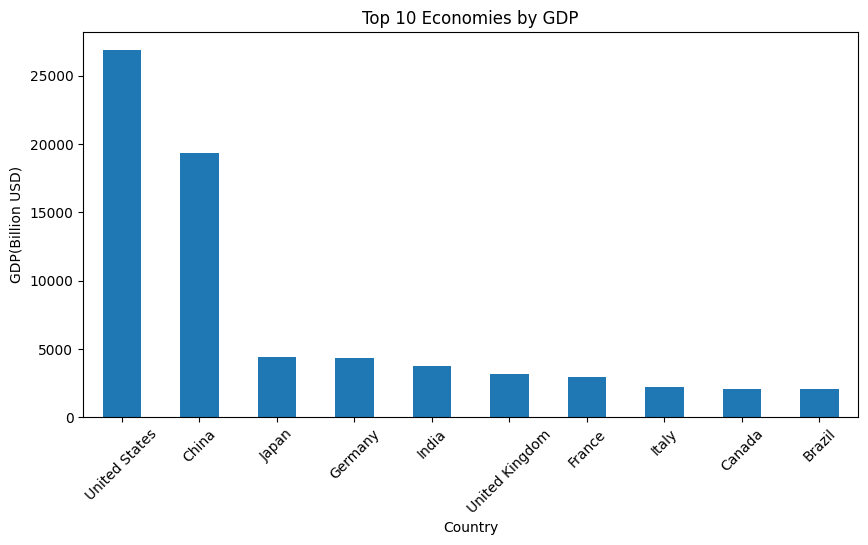

In [73]:
# Plot top 10 GDP economies
top10.plot(
    x="Country",
    y="GDP(Billion USD)",
    kind="bar",
    figsize=(10,5),
    legend=False
)

plt.title("Top 10 Economies by GDP")
plt.ylabel("GDP(Billion USD)")
plt.xticks(rotation=45)
plt.show()

In [74]:
## 6. Observations

# The United States has the largest GDP among all countries in the dataset.
# China and Japan follow as the next largest economies.
# A small number of countries have missing GDP values in the original source dataset.

In [75]:
## 7. Exporting Cleaned Data
gdp.to_csv("Largest_economies.csv", index=False)

In [76]:
## 8. Key Learnings

# This project was completed as part of a data analysis course and demonstrates the process of extracting and cleaning real-world data.
# Learned how to extract tabular data from a website using pandas.read_html().
# Practiced cleaning messy datasets by handling missing values and irrelevant records.
# Note: Some countries had missing GDP estimates in the source data.
# These were preserved as NaN values to maintain the integrity of the dataset rather than imputing artificial values.
# Converted data types and transformed GDP values from Million USD to Billion USD.
# Exported the processed dataset into a CSV file for further analysis.